# Logistic Regression

## Intuition

Logistic Regression is a probabilistic binary classifier. Unlike the Perceptron, which outputs a hard $+1$ or $-1$, Logistic Regression outputs a probability: how likely is this sample to belong to the positive class?

The key idea is to pass the linear combination $\mathbf{w} \cdot \mathbf{x} + b$ through the **sigmoid function**, which squashes any real number into the interval $(0, 1)$. The sigmoid has a natural S-shaped curve: large positive inputs give probabilities close to 1, large negative inputs give probabilities close to 0, and the decision boundary is at exactly 0.5.

Instead of minimizing squared error, we minimize **cross-entropy loss**, which penalizes confident wrong predictions very heavily (logarithmic penalty). This makes the model calibrated: a predicted probability of 0.9 should reflect a true positive rate of about 90%.

---

## Math

**Sigmoid function.**

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \mathbf{w} \cdot \mathbf{x} + b$$

**Predicted probability.**

$$\hat{p} = \sigma(\mathbf{w} \cdot \mathbf{x} + b) \in (0, 1)$$

**Decision rule.** Predict class 1 if $\hat{p} \geq 0.5$, else predict class 0. This threshold corresponds to $\mathbf{w} \cdot \mathbf{x} + b = 0$, which is a linear decision boundary.

**Binary Cross-Entropy Loss.**

$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y^{(i)} \log \hat{p}^{(i)} + (1 - y^{(i)}) \log(1 - \hat{p}^{(i)}) \right]$$

When $y=1$ and $\hat{p} \to 0$, the loss $\to \infty$. When $y=0$ and $\hat{p} \to 1$, the loss $\to \infty$. Correct confident predictions incur near-zero loss.

**SGD Update Rule.** The gradient of the cross-entropy with respect to $\mathbf{w}$ has the same form as linear regression:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha (\hat{p} - y) \mathbf{x}$$
$$b \leftarrow b - \alpha (\hat{p} - y)$$

---

## Algorithm Steps

1. Initialize $\mathbf{w} = \mathbf{0}$, $b = 0$.
2. For each epoch:
   - For each training sample $(\mathbf{x}^{(i)}, y^{(i)})$:
     - Compute $z = \mathbf{w} \cdot \mathbf{x}^{(i)} + b$.
     - Compute $\hat{p} = \sigma(z) = 1/(1+e^{-z})$.
     - Compute error $e = \hat{p} - y^{(i)}$.
     - Update: $\mathbf{w} \leftarrow \mathbf{w} - \alpha e \mathbf{x}^{(i)}$, $b \leftarrow b - \alpha e$.
3. Track cross-entropy loss per epoch.
4. At prediction time: $\hat{y} = 1$ if $\sigma(\mathbf{w} \cdot \mathbf{x} + b) \geq 0.5$ else $0$.

---

## Advantages

- Outputs calibrated probabilities, not just hard labels.
- The weights are interpretable: $e^{w_j}$ is the odds ratio for feature $j$.
- No strong distributional assumptions about the features.
- Efficient: converges quickly on linearly separable data.
- Works well as a baseline for binary classification.

## Disadvantages

- Assumes a linear decision boundary. fails on non-linearly-separable data without feature engineering.
- Assumes independence among features (no interaction terms by default).
- Can underfit complex data patterns.
- Requires feature scaling for stable gradient descent convergence.

## Solutions to Disadvantages

- Add **polynomial or interaction features** to model non-linear boundaries.
- Use **kernel SVM** or **decision trees** for inherently non-linear problems.
- Apply **L2 regularization** (logistic ridge) to handle correlated features and prevent overfitting.
- Use **Neural Networks** when complex multi-layer feature interactions are needed.

---

## Summary

| Property | Value |
|---|---|
| Type | Binary classifier |
| Decision boundary | Linear hyperplane |
| Output | Probability in $(0,1)$ |
| Loss | Binary Cross-Entropy |
| Optimization | Stochastic Gradient Descent |
| Key metric | Accuracy, AUC-ROC |
| Hyperparameters | Learning rate $\alpha$, epochs |

**Dataset:** Pima Indians Diabetes (`diabetes.csv`). 768 samples, 8 medical features. Predict diabetes diagnosis (Outcome: 0 = no, 1 = yes).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning import LogisticRegression
from rice_ml.preprocess import StandardScaler, train_test_split
from rice_ml.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
try:
    df = pd.read_csv('../../../data/diabetes.csv')
    X = df.drop(columns=['Outcome']).values.astype(float)
    y = df['Outcome'].values.astype(float)
    feature_names = df.drop(columns=['Outcome']).columns.tolist()
    print(f'Loaded diabetes dataset: {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    X, y = data.data[:, :8], data.target.astype(float)
    feature_names = list(data.feature_names[:8])
    df = None
    print('CSV not found. using breast cancer dataset (first 8 features)')

print(f'Positive cases: {int(y.sum())} / {len(y)}')

Loaded diabetes dataset: (768, 8)
Positive cases: 268 / 768


## Dataset Description

The **Pima Indians Diabetes dataset** (`diabetes.csv`) originates from the National Institute of Diabetes and Digestive and Kidney Diseases. It contains 768 female patients of Pima Indian heritage, aged 21 and older.

| Feature | Description |
|---|---|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration at 2 hours in an oral glucose tolerance test (mg/dL) |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skinfold thickness (mm) |
| Insulin | 2-Hour serum insulin (mu U/ml) |
| BMI | Body mass index (weight in kg / height in m squared) |
| DiabetesPedigreeFunction | Diabetes pedigree function (family history likelihood score) |
| Age | Age in years |

**Target:** `Outcome` (1 = diabetic, 0 = not diabetic). The dataset has 268 positive cases (34.9%) and 500 negative cases (65.1%), making it moderately imbalanced.

Glucose level and BMI are widely considered the strongest predictors of diabetes risk in this population.

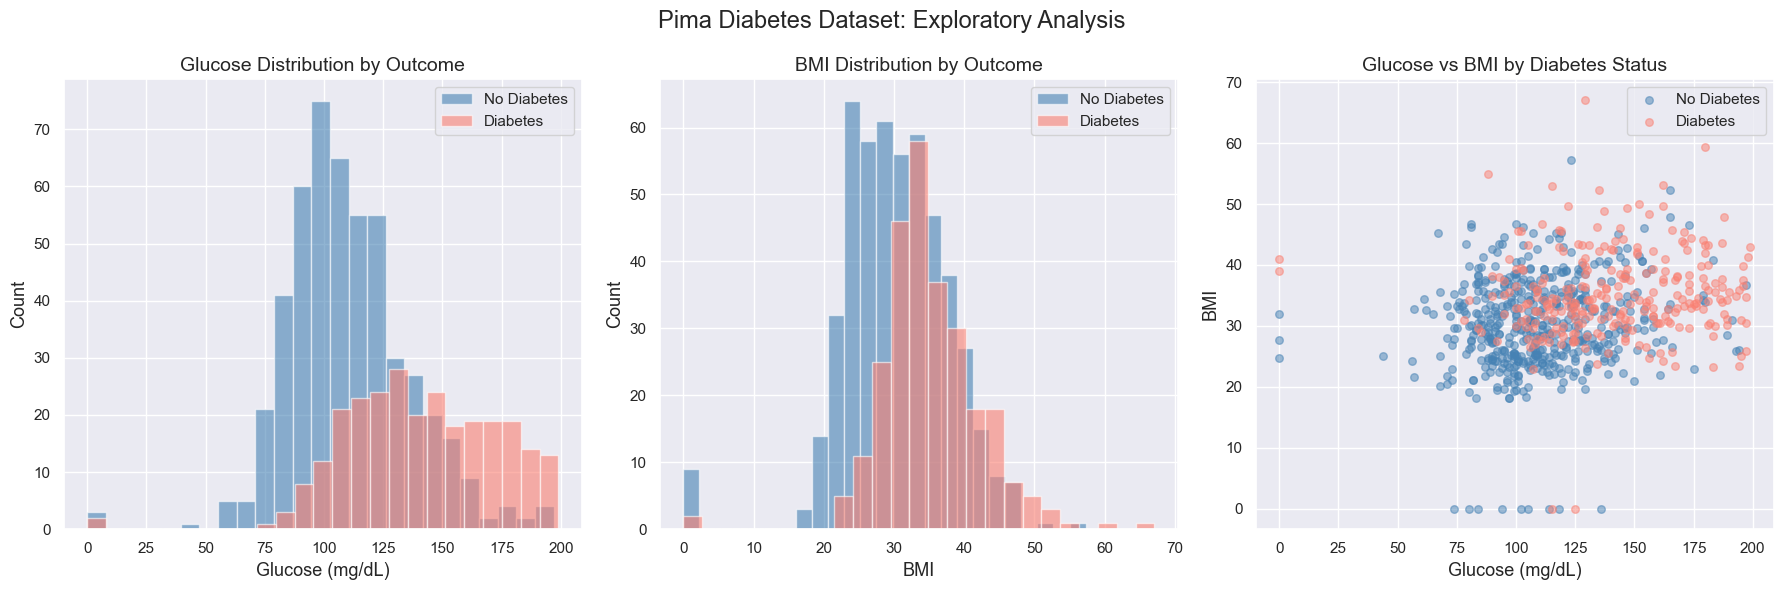

Mean Glucose:  No Diabetes = 110.0, Diabetes = 141.3
Mean BMI:      No Diabetes = 30.3, Diabetes = 35.1


In [3]:
# EDA: Distributions of Glucose and BMI split by Outcome
if df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Glucose distribution by class
    for outcome, color, label in [(0, 'steelblue', 'No Diabetes'), (1, 'salmon', 'Diabetes')]:
        mask = df['Outcome'] == outcome
        axes[0].hist(df.loc[mask, 'Glucose'], bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[0].set_xlabel('Glucose (mg/dL)', fontsize=13)
    axes[0].set_ylabel('Count', fontsize=13)
    axes[0].set_title('Glucose Distribution by Outcome', fontsize=14)
    axes[0].legend(fontsize=11)

    # BMI distribution by class
    for outcome, color, label in [(0, 'steelblue', 'No Diabetes'), (1, 'salmon', 'Diabetes')]:
        mask = df['Outcome'] == outcome
        axes[1].hist(df.loc[mask, 'BMI'], bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[1].set_xlabel('BMI', fontsize=13)
    axes[1].set_ylabel('Count', fontsize=13)
    axes[1].set_title('BMI Distribution by Outcome', fontsize=14)
    axes[1].legend(fontsize=11)

    # Scatter: Glucose vs BMI colored by class
    for outcome, color, label in [(0, 'steelblue', 'No Diabetes'), (1, 'salmon', 'Diabetes')]:
        mask = df['Outcome'] == outcome
        axes[2].scatter(df.loc[mask, 'Glucose'], df.loc[mask, 'BMI'],
                        c=color, label=label, alpha=0.5, s=30)
    axes[2].set_xlabel('Glucose (mg/dL)', fontsize=13)
    axes[2].set_ylabel('BMI', fontsize=13)
    axes[2].set_title('Glucose vs BMI by Diabetes Status', fontsize=14)
    axes[2].legend(fontsize=11)

    plt.suptitle('Pima Diabetes Dataset: Exploratory Analysis', fontsize=17)
    plt.tight_layout()
    plt.show()

    print('Mean Glucose:  No Diabetes = {:.1f}, Diabetes = {:.1f}'.format(
        df.loc[df['Outcome']==0, 'Glucose'].mean(),
        df.loc[df['Outcome']==1, 'Glucose'].mean()))
    print('Mean BMI:      No Diabetes = {:.1f}, Diabetes = {:.1f}'.format(
        df.loc[df['Outcome']==0, 'BMI'].mean(),
        df.loc[df['Outcome']==1, 'BMI'].mean()))
else:
    print('EDA skipped: using fallback dataset.')

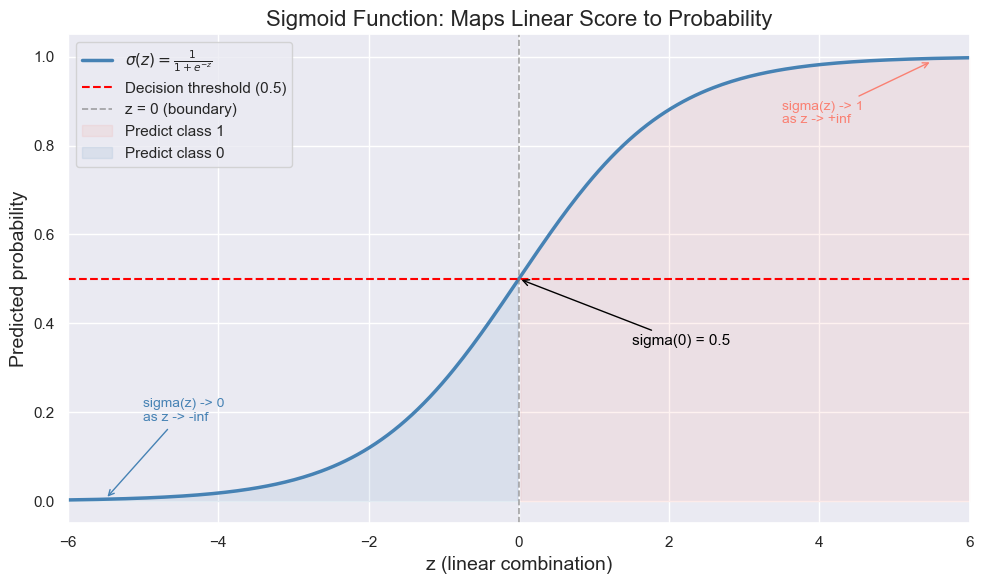

In [4]:
# Diagram: The sigmoid function
z = np.linspace(-6, 6, 300)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(z, sigma, color='steelblue', lw=2.5, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
ax.axhline(0.5, color='red', linestyle='--', lw=1.5, label='Decision threshold (0.5)')
ax.axvline(0, color='gray', linestyle='--', lw=1.2, alpha=0.7, label='z = 0 (boundary)')

# Shade the two decision regions
ax.fill_between(z, 0, sigma, where=(z >= 0), alpha=0.10, color='salmon', label='Predict class 1')
ax.fill_between(z, 0, sigma, where=(z < 0), alpha=0.10, color='steelblue', label='Predict class 0')

# Annotate key points
ax.annotate('sigma(0) = 0.5', xy=(0, 0.5), xytext=(1.5, 0.35),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11, color='black')
ax.annotate('sigma(z) -> 1\nas z -> +inf', xy=(5.5, 0.99), xytext=(3.5, 0.85),
            arrowprops=dict(arrowstyle='->', color='salmon'),
            fontsize=10, color='salmon')
ax.annotate('sigma(z) -> 0\nas z -> -inf', xy=(-5.5, 0.005), xytext=(-5.0, 0.18),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            fontsize=10, color='steelblue')

ax.set_xlabel('z (linear combination)', fontsize=14)
ax.set_ylabel('Predicted probability', fontsize=14)
ax.set_title('Sigmoid Function: Maps Linear Score to Probability', fontsize=16)
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-6, 6)
plt.tight_layout()
plt.show()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Train. Stochastic Gradient Descent

Each epoch processes one sample at a time and updates $\mathbf{w}$ and $b$ using the gradient of the cross-entropy loss.

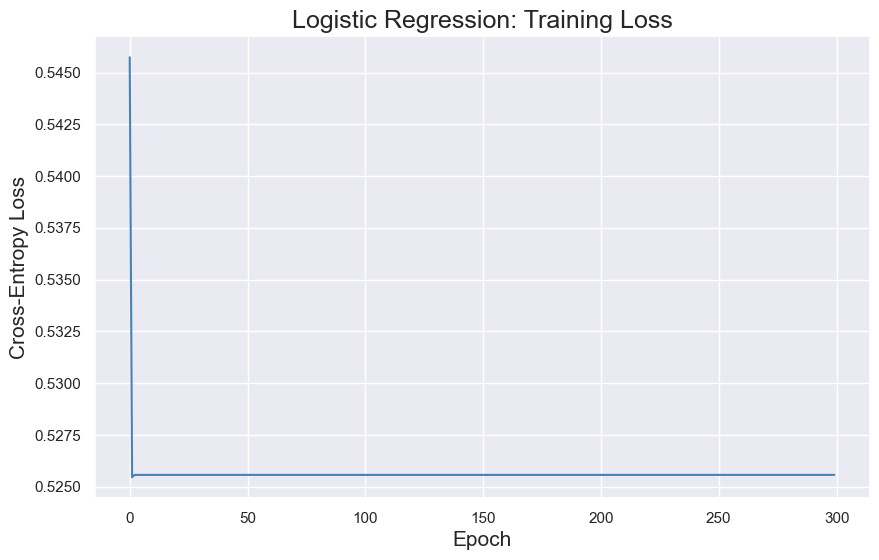

In [6]:
model = LogisticRegression(alpha=0.1, epochs=300)
model.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
plt.plot(model.errors_, color='steelblue')
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Cross-Entropy Loss', fontsize=15)
plt.title('Logistic Regression: Training Loss', fontsize=18)
plt.show()

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
report = classification_report(y_test, y_pred)
for cls, metrics in report.items():
    print(f'  {cls:15s}: {metrics}')

Test Accuracy: 0.7712

  0.0            : {'precision': np.float64(0.8247), 'recall': np.float64(0.8163), 'f1-score': np.float64(0.8205), 'support': 98}
  1.0            : {'precision': np.float64(0.6786), 'recall': np.float64(0.6909), 'f1-score': np.float64(0.6847), 'support': 55}
  macro avg      : {'precision': 0.7516, 'recall': 0.7536, 'f1-score': 0.7526, 'support': 153}
  weighted avg   : {'precision': 0.7722, 'recall': 0.7712, 'f1-score': 0.7717, 'support': 153}


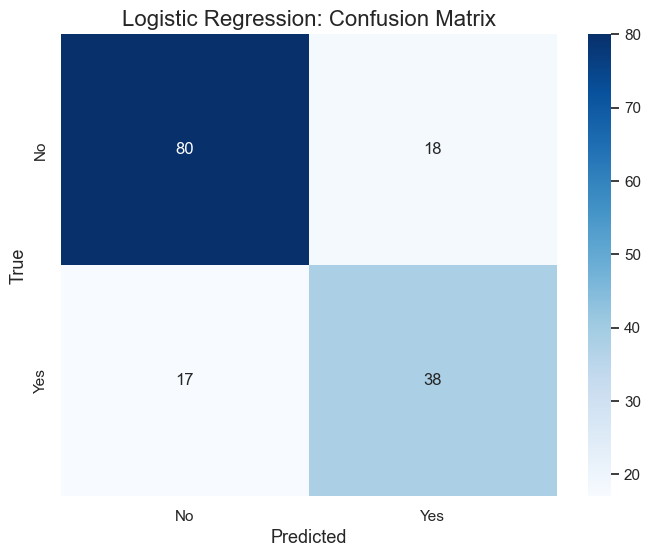

In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('True', fontsize=13)
plt.title('Logistic Regression: Confusion Matrix', fontsize=16)
plt.show()

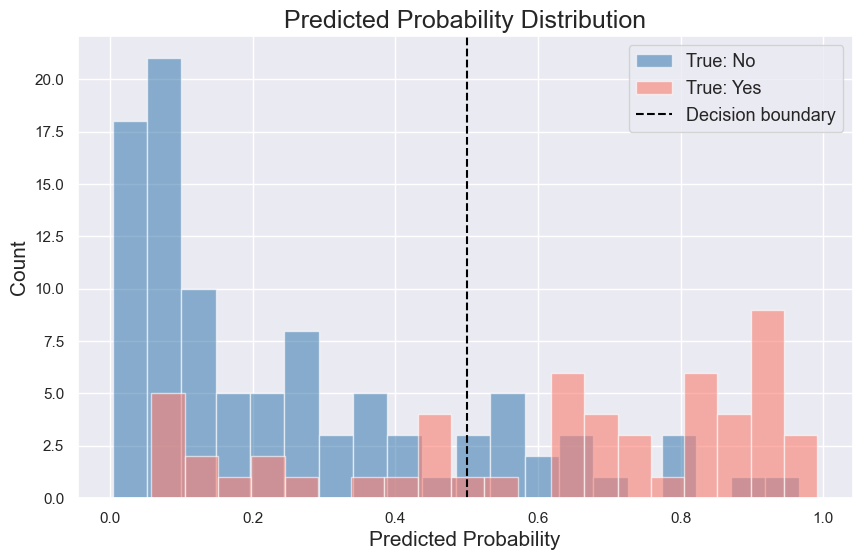

In [9]:
# Predicted probability distribution
plt.figure(figsize=(10, 6))
plt.hist(y_proba[y_test == 0], bins=20, alpha=0.6, color='steelblue', label='True: No')
plt.hist(y_proba[y_test == 1], bins=20, alpha=0.6, color='salmon', label='True: Yes')
plt.axvline(0.5, color='black', linestyle='--', label='Decision boundary')
plt.xlabel('Predicted Probability', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title('Predicted Probability Distribution', fontsize=18)
plt.legend(fontsize=13)
plt.show()

## Interpretation

**Sigmoid and decision boundary:** The sigmoid diagram shows that the model is fully determined by the linear boundary $\mathbf{w} \cdot \mathbf{x} + b = 0$. Samples with a large positive linear score receive high predicted probabilities; samples with a large negative score receive low predicted probabilities.

**Cross-entropy loss curve:** The decreasing training loss confirms that gradient descent is working correctly. A loss that plateaus early may indicate too small a learning rate or insufficient epochs.

**Probability histogram:** Good separation between the blue (true negatives) and red (true positives) distributions indicates the model has learned meaningful signal. Overlap near 0.5 represents borderline cases where the model is uncertain.

**Feature weights (clinical insight):** After standardization, the weight $w_j$ for Glucose will typically be the largest positive weight, confirming clinical knowledge that elevated plasma glucose is the strongest single predictor of diabetes.

**False negatives:** In a diabetes screening context, false negatives (missing a diabetic patient) are more costly than false positives. The decision threshold of 0.5 can be lowered (e.g., to 0.3) to increase recall at the cost of precision.